In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pennylane as qml
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_FEATURES = 4

N_QVAF_QUBITS = 2

QVAF_LAYERS = 3

USE_PCA = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch device:", device)
print("PennyLane:", qml.__version__)
print("Input features:", N_FEATURES)
print("QVAF qubits:", N_QVAF_QUBITS)
print("QVAF layers:", QVAF_LAYERS)


PyTorch device: cuda
PennyLane: 0.45.1
Input features: 4
QVAF qubits: 2
QVAF layers: 3


In [ ]:
data = load_breast_cancer()

X = data.data.astype(np.float32)
feature_names = np.array(data.feature_names)
y = (data.target == 0).astype(np.float32)

print("Dataset shape:", X.shape)
print("Benign:", int(np.sum(y == 0)))
print("Malignant:", int(np.sum(y == 1)))


Dataset shape: (569, 30)
Benign: 357
Malignant: 212


In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nClass counts:")
print("Train      :", np.bincount(y_train.astype(int)))
print("Validation :", np.bincount(y_val.astype(int)))
print("Test       :", np.bincount(y_test.astype(int)))


Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)

Class counts:
Train      : [250 148]
Validation : [53 32]
Test       : [54 32]


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

if USE_PCA:
    reducer = PCA(
        n_components=N_FEATURES,
        random_state=SEED
    )

    X_train_reduced = reducer.fit_transform(X_train_scaled)
    X_val_reduced = reducer.transform(X_val_scaled)
    X_test_reduced = reducer.transform(X_test_scaled)

    selected_feature_names = [
        f"PC{i+1}" for i in range(N_FEATURES)
    ]

    print(
        "4-PC explained variance:",
        reducer.explained_variance_ratio_.sum()
    )

else:
    reducer = SelectKBest(
        score_func=f_classif,
        k=N_FEATURES
    )

    X_train_reduced = reducer.fit_transform(
        X_train_scaled,
        y_train
    )
    X_val_reduced = reducer.transform(X_val_scaled)
    X_test_reduced = reducer.transform(X_test_scaled)

    mask = reducer.get_support()

    selected_feature_names = feature_names[mask].tolist()

    feature_scores = pd.DataFrame({
        "Feature": feature_names[mask],
        "F-score": reducer.scores_[mask]
    }).sort_values(
        "F-score",
        ascending=False
    )

    display(feature_scores)

print("\nReduced shapes:")
print("Train:", X_train_reduced.shape)
print("Validation:", X_val_reduced.shape)
print("Test:", X_test_reduced.shape)


,Feature,F-score
2,worst perimeter,619.823837
3,worst concave points,612.840343
1,worst radius,595.042853
0,mean concave points,569.210578



Reduced shapes:
Train: (398, 4)
Validation: (85, 4)
Test: (86, 4)


In [5]:
def prepare_quantum_input(X):
    # Bound the four selected features.
    return np.tanh(
        np.asarray(X, dtype=np.float32)
    )

X_train_q = torch.tensor(
    prepare_quantum_input(X_train_reduced),
    dtype=torch.float32
)

X_val_q = torch.tensor(
    prepare_quantum_input(X_val_reduced),
    dtype=torch.float32
)

X_test_q = torch.tensor(
    prepare_quantum_input(X_test_reduced),
    dtype=torch.float32
)

y_train_t = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1, 1)

y_val_t = torch.tensor(
    y_val,
    dtype=torch.float32
).view(-1, 1)

y_test_t = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1, 1)

print("QKAN input shape:", X_train_q.shape)


QKAN input shape: torch.Size([398, 4])


In [6]:
qvaf_dev = qml.device(
    "default.qubit",
    wires=N_QVAF_QUBITS
)

@qml.qnode(
    qvaf_dev,
    interface="torch",
    diff_method="backprop"
)
def qvaf_circuit(x, weights):

    x = torch.clamp(x, -1.0, 1.0)

    x2 = x ** 2
    sin_x = torch.sin(x)

    # Richer encoding on the same two qubits.
    for wire in range(N_QVAF_QUBITS):
        qml.RY(x, wires=wire)
        qml.RZ(x2, wires=wire)
        qml.RX(sin_x, wires=wire)

    # Three trainable variational layers.
    for layer in range(QVAF_LAYERS):

        for wire in range(N_QVAF_QUBITS):
            qml.Rot(
                weights[layer, wire, 0],
                weights[layer, wire, 1],
                weights[layer, wire, 2],
                wires=wire
            )

        qml.CNOT(wires=[0, 1])

    return qml.expval(
        qml.PauliZ(0)
    )

demo_weights = 0.1 * torch.randn(
    QVAF_LAYERS,
    N_QVAF_QUBITS,
    3
)

print(
    "QVAF output:",
    qvaf_circuit(
        torch.tensor(0.5),
        demo_weights
    )
)


QVAF output: tensor(0.6877, dtype=torch.float64)


In [7]:
class QVAF(nn.Module):

    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(
            0.1 * torch.randn(
                QVAF_LAYERS,
                N_QVAF_QUBITS,
                3
            )
        )

    def forward(self, x):

        outputs = []

        for value in x:
            outputs.append(
                qvaf_circuit(
                    value,
                    self.weights
                )
            )

        return torch.stack(
            outputs
        ).view(-1, 1)


In [8]:
class QKANLayer(nn.Module):

    def __init__(
        self,
        in_features,
        out_features
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        self.qvafs = nn.ModuleList([
            nn.ModuleList([
                QVAF()
                for _ in range(in_features)
            ])
            for _ in range(out_features)
        ])

        self.edge_scale = nn.Parameter(
            0.1 * torch.randn(
                out_features,
                in_features
            )
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

    def forward(self, x):

        outputs = []

        for j in range(self.out_features):

            edge_outputs = []

            for i in range(self.in_features):

                q_value = self.qvafs[j][i](
                    x[:, i]
                )

                edge_outputs.append(
                    self.edge_scale[j, i]
                    * q_value
                )

            y_j = torch.cat(
                edge_outputs,
                dim=1
            ).sum(dim=1)

            y_j = y_j + self.bias[j]

            outputs.append(y_j)

        return torch.stack(
            outputs,
            dim=1
        )


In [9]:
class QKANClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.qkan1 = QKANLayer(
            in_features=4,
            out_features=6
        )

        self.qkan2 = QKANLayer(
            in_features=6,
            out_features=3
        )

        self.qkan3 = QKANLayer(
            in_features=3,
            out_features=1
        )

    def forward(self, x):

        x = self.qkan1(x)
        x = self.qkan2(x)
        x = self.qkan3(x)

        return x


model = QKANClassifier()

print(model)

print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


QKANClassifier(
  (qkan1): QKANLayer(
    (qvafs): ModuleList(
      (0-5): 6 x ModuleList(
        (0-3): 4 x QVAF()
      )
    )
  )
  (qkan2): QKANLayer(
    (qvafs): ModuleList(
      (0-2): 3 x ModuleList(
        (0-5): 6 x QVAF()
      )
    )
  )
  (qkan3): QKANLayer(
    (qvafs): ModuleList(
      (0): ModuleList(
        (0-2): 3 x QVAF()
      )
    )
  )
)

Trainable parameters: 865


In [10]:
n_benign = np.sum(
    y_train == 0
)

n_malignant = np.sum(
    y_train == 1
)

pos_weight_value = (
    n_benign / n_malignant
)

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32
)

print(
    "Benign training samples:",
    n_benign
)

print(
    "Malignant training samples:",
    n_malignant
)

print(
    "Malignant loss weight:",
    pos_weight_value
)


Benign training samples: 250
Malignant training samples: 148
Malignant loss weight: 1.6891891891891893


In [ ]:
class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.75,
        gamma=2.0
    ):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(
        self,
        logits,
        targets
    ):

        bce = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(
            logits
        )

        pt = torch.where(
            targets == 1,
            probs,
            1 - probs
        )

        alpha_t = torch.where(
            targets == 1,
            torch.full_like(
                logits,
                self.alpha
            ),
            torch.full_like(
                logits,
                1 - self.alpha
            )
        )

        return (
            alpha_t
            * (1 - pt) ** self.gamma
            * bce
        ).mean()

USE_FOCAL_LOSS = False

if USE_FOCAL_LOSS:
    criterion = FocalLoss(
        alpha=0.75,
        gamma=2.0
    )
    print("Using Focal Loss")
else:
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )
    print("Using weighted BCE")


Using weighted BCE


In [12]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

EPOCHS = 150
PATIENCE = 25

train_losses = []
val_losses = []
val_f1_history = []
val_recall_history = []

best_f1 = -np.inf
best_state = None
patience_counter = 0

for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    optimizer.zero_grad()

    train_logits = model(
        X_train_q
    )

    train_loss = criterion(
        train_logits,
        y_train_t
    )

    train_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_logits = model(
            X_val_q
        )

        val_loss = nn.BCEWithLogitsLoss()(
            val_logits,
            y_val_t
        )

        val_probs = torch.sigmoid(
            val_logits
        ).numpy().ravel()

    val_preds = (
        val_probs >= 0.5
    ).astype(int)

    val_f1 = f1_score(
        y_val.astype(int),
        val_preds,
        zero_division=0
    )

    val_recall = recall_score(
        y_val.astype(int),
        val_preds,
        zero_division=0
    )

    train_losses.append(
        train_loss.item()
    )

    val_losses.append(
        val_loss.item()
    )

    val_f1_history.append(
        val_f1
    )

    val_recall_history.append(
        val_recall
    )

    if val_f1 > best_f1:

        best_f1 = val_f1

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        patience_counter = 0

    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {train_loss.item():.4f} | "
            f"Val Loss {val_loss.item():.4f} | "
            f"Val F1 {val_f1:.4f} | "
            f"Val Recall {val_recall:.4f}"
        )

    if patience_counter >= PATIENCE:

        print(
            "Early stopping at epoch",
            epoch
        )

        break

model.load_state_dict(
    best_state
)

print(
    "\nBest validation malignant F1:",
    best_f1
)


Epoch 001 | Train Loss 0.8717 | Val Loss 0.6886 | Val F1 0.0000 | Val Recall 0.0000
Epoch 010 | Train Loss 0.8707 | Val Loss 0.6911 | Val F1 0.0000 | Val Recall 0.0000
Epoch 020 | Train Loss 0.8690 | Val Loss 0.6927 | Val F1 0.5470 | Val Recall 1.0000
Epoch 030 | Train Loss 0.8370 | Val Loss 0.6627 | Val F1 0.9275 | Val Recall 1.0000
Epoch 040 | Train Loss 0.7107 | Val Loss 0.5541 | Val F1 0.9254 | Val Recall 0.9688
Epoch 050 | Train Loss 0.5469 | Val Loss 0.4223 | Val F1 0.9091 | Val Recall 0.9375
Early stopping at epoch 55

Best validation malignant F1: 0.927536231884058


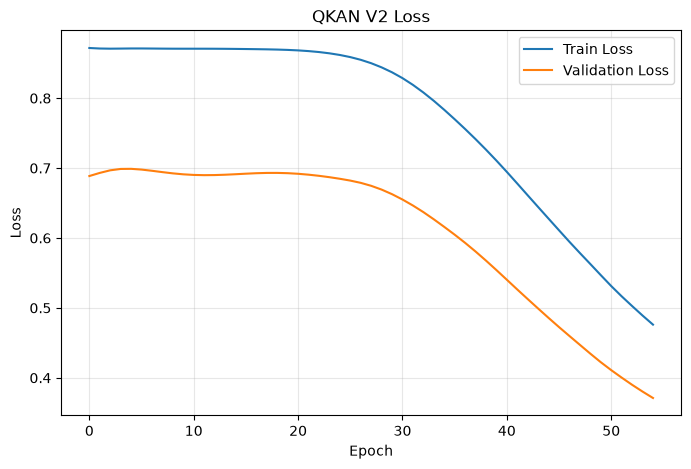

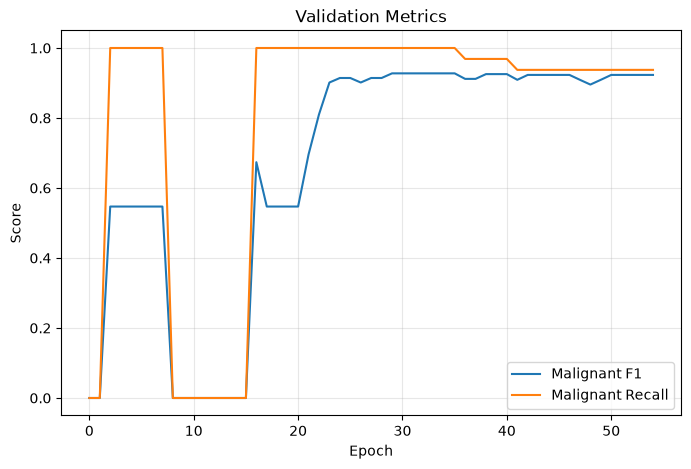

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("QKAN V2 Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    val_f1_history,
    label="Malignant F1"
)

plt.plot(
    val_recall_history,
    label="Malignant Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [14]:
model.eval()

with torch.no_grad():

    val_probs = torch.sigmoid(
        model(X_val_q)
    ).numpy().ravel()

thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

rows = []

for threshold in thresholds:

    preds = (
        val_probs >= threshold
    ).astype(int)

    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_val,
            preds
        ),
        "precision": precision_score(
            y_val,
            preds,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            preds,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            preds,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    rows
)

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["threshold"]
)

print(
    f"Selected threshold: {BEST_THRESHOLD:.2f}"
)

print(
    f"Validation accuracy: "
    f"{best_row['accuracy']:.4f}"
)

print(
    f"Validation malignant recall: "
    f"{best_row['recall']:.4f}"
)

print(
    f"Validation malignant F1: "
    f"{best_row['f1']:.4f}"
)


Selected threshold: 0.50
Validation accuracy: 0.9412
Validation malignant recall: 1.0000
Validation malignant F1: 0.9275


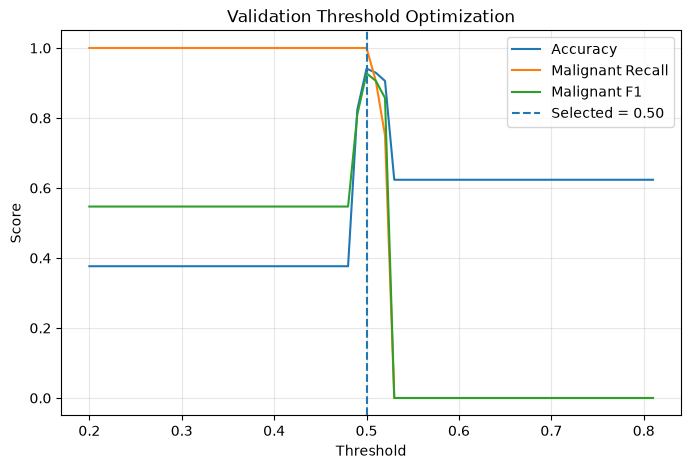

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Malignant Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="Malignant F1"
)

plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Selected = {BEST_THRESHOLD:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Optimization")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [16]:
model.eval()

with torch.no_grad():

    test_probs = torch.sigmoid(
        model(X_test_q)
    ).numpy().ravel()

y_true = y_test.astype(int)

y_pred = (
    test_probs >= BEST_THRESHOLD
).astype(int)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_true,
    test_probs
)

print(
    f"Threshold: {BEST_THRESHOLD:.2f}"
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

print(
    f"ROC-AUC  : {auc:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)


Threshold: 0.50
Accuracy : 0.9884
Precision: 0.9697
Recall   : 1.0000
F1-score : 0.9846
ROC-AUC  : 0.9994

Classification Report:
              precision    recall  f1-score   support

      Benign     1.0000    0.9815    0.9907        54
   Malignant     0.9697    1.0000    0.9846        32

    accuracy                         0.9884        86
   macro avg     0.9848    0.9907    0.9876        86
weighted avg     0.9887    0.9884    0.9884        86



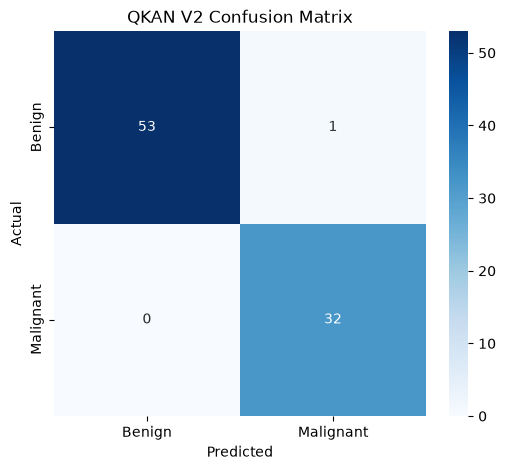

In [17]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QKAN V2 Confusion Matrix")

plt.show()


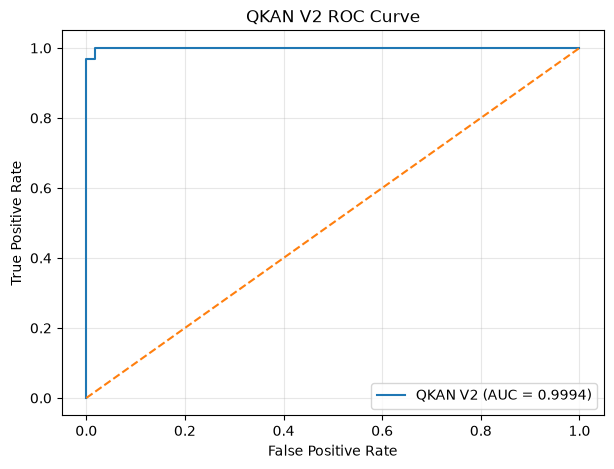

In [18]:
fpr, tpr, _ = roc_curve(
    y_true,
    test_probs
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"QKAN V2 (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("QKAN V2 ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [19]:
pred_05 = (
    test_probs >= 0.50
).astype(int)

pred_opt = (
    test_probs >= BEST_THRESHOLD
).astype(int)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Malignant Precision",
        "Malignant Recall",
        "Malignant F1"
    ],
    "Threshold 0.50": [
        accuracy_score(
            y_true,
            pred_05
        ),
        precision_score(
            y_true,
            pred_05,
            zero_division=0
        ),
        recall_score(
            y_true,
            pred_05,
            zero_division=0
        ),
        f1_score(
            y_true,
            pred_05,
            zero_division=0
        )
    ],
    "Optimized Threshold": [
        accuracy_score(
            y_true,
            pred_opt
        ),
        precision_score(
            y_true,
            pred_opt,
            zero_division=0
        ),
        recall_score(
            y_true,
            pred_opt,
            zero_division=0
        ),
        f1_score(
            y_true,
            pred_opt,
            zero_division=0
        )
    ]
})

display(
    comparison
)


,Metric,Threshold 0.50,Optimized Threshold
0,Accuracy,0.988372,0.988372
1,Malignant Precision,0.969697,0.969697
2,Malignant Recall,1.000000,1.000000
3,Malignant F1,0.984615,0.984615
